In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "mrpc"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 3668
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1'], raw_train_dataset[5]['sentence2']

('Revenue in the first quarter of the year dropped 15 percent from the same period a year earlier .',
 "With the scandal hanging over Stewart 's company , revenue the first quarter of the year dropped 15 percent from the same period a year earlier .")

In [11]:
raw_train_dataset[5]['label']

1

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 100]),
 'token_type_ids': torch.Size([32, 100]),
 'attention_mask': torch.Size([32, 100])}

# 4. Load Model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(1.2996, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
teacher_model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
teacher_model.set_use_module_grafting(False)
teacher_model.set_use_scc_status(False)

In [27]:
outputs = teacher_model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.6582, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [28]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
teacher_model.to(device)

device

device(type='cuda', index=1)

### Load Trained Weights

In [29]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [30]:
from train_eval_func import eval_loop

In [31]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

In [32]:
teacher_model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [33]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

# 5. Contribution Layer Drop

In [34]:
from layer_drop import layer_drop

In [35]:
from layer_merge_helper import reorder_merged_layer_heads, reorder_merged_layer_neurons

In [36]:
from structure_prune_helper import compute_importance_scores, register_importance_masks, remove_importance_masks

In [37]:
register_importance_masks(model, device, register_heads=True, register_ffn=True)

  Layer 0: Registered masks (12 heads, 3072 neurons)
  Layer 1: Registered masks (12 heads, 3072 neurons)
  Layer 2: Registered masks (12 heads, 3072 neurons)
  Layer 3: Registered masks (12 heads, 3072 neurons)
  Layer 4: Registered masks (12 heads, 3072 neurons)
  Layer 5: Registered masks (12 heads, 3072 neurons)
  Layer 6: Registered masks (12 heads, 3072 neurons)
  Layer 7: Registered masks (12 heads, 3072 neurons)
  Layer 8: Registered masks (12 heads, 3072 neurons)
  Layer 9: Registered masks (12 heads, 3072 neurons)
  Layer 10: Registered masks (12 heads, 3072 neurons)
  Layer 11: Registered masks (12 heads, 3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [38]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

In [39]:
init_metric = eval_loop(model, val_dataloader, task_name, device)[0]
init_metric

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

In [40]:
performance_track = layer_drop(
    model, train_dataloader, val_dataloader, task_name, device, init_metric=init_metric, num_merges=9,
    cka_evaluator=cka_eval, teacher_model=teacher_model, drop_strategy="top_merge"
)

Target Metric for mrpc: f1
Original f1 score: 0.9094
Recovery threshold: 0.0091

Merge Iteration: 1/9
Drop Layer: 10


Computing importance (heads + FFN): 100%|██████████| 115/115 [00:16<00:00,  6.95it/s]


9 7
2562 1534
Number of Layers Remaining: 11
  Metrics:
      accuracy: 0.8799
    ★ f1: 0.9165
  Performance drop: -0.0071 (threshold: 0.0091)
  → Recovery training NOT needed
  • 11 layers (not in target list, skipping save)
Merge Iteration: 2/9
Drop Layer: 9


Computing importance (heads + FFN): 100%|██████████| 115/115 [00:14<00:00,  8.01it/s]


11 9
2785 2335
Number of Layers Remaining: 10
  Metrics:
      accuracy: 0.8799
    ★ f1: 0.9160
  Performance drop: -0.0066 (threshold: 0.0091)
  → Recovery training NOT needed
  • 10 layers (not in target list, skipping save)
Merge Iteration: 3/9
Drop Layer: 8


...

Training:  30%|██▉       | 344/1150 [01:01<01:19, 10.17it/s]


<----------------- Epoch 3 ----------------->
Loss: 1.2, Training Metrics:
  accuracy: 0.8814
  f1: 0.9153
Validation Loss: 1.37, Validation Metrics:
  accuracy: 0.7353
  f1: 0.8269
Elapsed Time: 15.4233 sec


Training:  40%|████      | 460/1150 [01:18<01:57,  5.89it/s]


<----------------- Epoch 4 ----------------->
Loss: 0.77, Training Metrics:
  accuracy: 0.9250
  f1: 0.9454
Validation Loss: 1.47, Validation Metrics:
  accuracy: 0.7304
  f1: 0.8214
Elapsed Time: 15.8661 sec
>>>>> Early stopping callback <<<<<

Total Training Time: 77.98 sec
Chosen Primary Metric: f1
Best Metric Run: 0.8359

  → Loading best checkpoint...


  ✓ Loaded best checkpoint from epoch 2
    Best val loss: 1.5297
    Best val metrics: {'accuracy': 0.7352941176470589, 'f1': 0.8358662613981763}
  ✓ Cleaned up temporary checkpoint
  ✓ Saved 3-layer model to ./weights/top_merge/layer-3-mrpc.pt


In [41]:
performance_track

{'performance_track': [{'accuracy': 0.8676470588235294,
   'f1': 0.9093959731543624},
  {'accuracy': 0.8799019607843137, 'f1': 0.9165247018739353},
  {'accuracy': 0.8799019607843137, 'f1': 0.9159519725557461},
  {'accuracy': 0.8725490196078431, 'f1': 0.9115646258503401},
  {'accuracy': 0.8725490196078431, 'f1': 0.910958904109589},
  {'accuracy': 0.8627450980392157, 'f1': 0.9066666666666666},
  {'accuracy': 0.8578431372549019, 'f1': 0.9016949152542373},
  {'accuracy': 0.8112745098039216, 'f1': 0.8723051409618574},
  {'accuracy': 0.8063725490196079, 'f1': 0.8676716917922948},
  {'accuracy': 0.7352941176470589, 'f1': 0.8358662613981763}],
 'remaining_layers': [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],


In [42]:
torch.save(performance_track, f'./weights/top_merge/performance_track_{task_name}.pt')

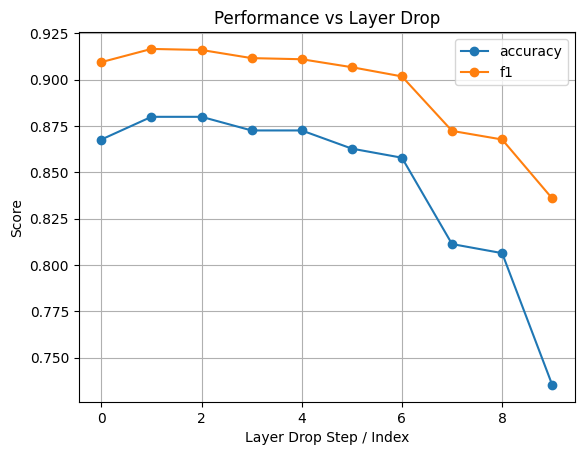

In [43]:
import matplotlib.pyplot as plt

performance_track = performance_track['performance_track']

# get all metric names dynamically
metrics = performance_track[0].keys()

x = list(range(len(performance_track)))  # e.g., layer index or drop step

plt.figure()

for metric in metrics:
    y = [entry.get(metric, None) for entry in performance_track]
    plt.plot(x, y, marker='o', label=metric)

plt.xlabel("Layer Drop Step / Index")
plt.ylabel("Score")
plt.title("Performance vs Layer Drop")
plt.legend()
plt.grid()

plt.show()